In [16]:
#!/usr/bin/env python3

import os
import yaml
import cv2
import numpy as np
import tkinter as tk
from threading import Thread


from PIL import Image, ImageTk

class CameraReaderNode():

    def __init__(self, node_name):
        # static parameters
        self._vehicle_name ='tick' #os.environ['VEHICLE_NAME']
        
        with open('packages/followlane/config/detect_lane.yaml','r') as f:
            text = f.read()
        self.conf = yaml.safe_load(text)

        self.create_window()

        self.is_running = False

    def callback(self,img):

        if self.is_running:
            return
        self.is_running = True

        print(f'call back called')
        self.update_conf()
        print(f'config updated')

        #print('started Method')
        # convert JPEG bytes to CV image
        image = img
        #print(f'converted image')
        # display frame
        image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
        #print(f'loaded image {image.shape}')
        print(f'read image {image.size}')
        if self.selected.get() == 'lane_image':

            x_alt = 0
            y_alt = 0
            for point in ['top_left','top_right','bottom_left','bottom_right','top_left']:
                x = self.conf['lane_image'][f'{point}_x']
                y = self.conf['lane_image'][f'{point}_y']

                if x_alt != 0 or y_alt != 0:
                    image = cv2.line(image,(x_alt,y_alt),(x,y),(255,255,255),2 )

                x_alt = x
                y_alt = y

        elif self.selected.get() == 'pid_regler'  or self.selected.get() == 'turn_control':
            pass
        elif self.selected.get() == 'turn_detect':
            image = cv2.circle(image,(self.conf['turn_detect']['left_x'], self.conf['turn_detect']['left_y']),20,(255,0,0))
            image = cv2.circle(image,(self.conf['turn_detect']['right_x'], self.conf['turn_detect']['right_y']),20,(255,0,0))
            image = cv2.circle(image,(self.conf['turn_detect']['front_x'], self.conf['turn_detect']['front_y']),20,(255,0,0))

        else:
            hl = self.conf[self.selected.get()]['hl']
            hh = self.conf[self.selected.get()]['hh'] 
            sl = self.conf[self.selected.get()]['sl']
            sh = self.conf[self.selected.get()]['sh']
            vl = self.conf[self.selected.get()]['vl']
            vh = self.conf[self.selected.get()]['vh'] 

            image = cv2.inRange(image, 
                            (hl,sl,vl), 
                            (hh,sh,vh),)

        print('showing image')
        #update image in window
        image = ImageTk.PhotoImage(Image.fromarray(image))
        self.panel.configure(image=image)
        self.panel.image = image

        print('done')
        self.is_running = False

    def update_conf(self):
        selected = self.selected.get()
        for val in self.conf[self.selected.get()]:
            name = f'{selected}_{val}'
            try:
                self.conf[selected][val] = self.sliders[name].get()
            except:
                print('bad conding should not happen')  

    
    def print_conf(self):
        text = yaml.safe_dump(self.conf)
        print(f'#############\n{text}\n#############')

    def change_menue(self,*args):
        self.slider_frame.pack_forget()
        print(f'selected menue : {self.selected.get()}')
        self.slider_frame = self.slider_frames[self.selected.get()]
        self.slider_frame.pack()
        self.print_conf()

    def create_window(self):
        self._root = tk.Tk()

        #Add Image For start only Black
        img = ImageTk.PhotoImage(Image.fromarray(np.zeros([480,640,3], np.uint8)))

        self.panel = tk.Label(self._root, image = img)
        self.panel.pack(side='bottom')

        #Add drop down menu
        options = [s for s in self.conf]

        self.selected = tk.StringVar(self._root)
        self.selected.set(options[0])
        self.selected.trace("w", lambda *args : self.change_menue(*args))

        self.dropdown = tk.OptionMenu(self._root, self.selected, *options)
        self.dropdown.pack(side='top')

        #Add sliders
        self.sliders = {}
        self.slider_frames = {}
        for option in options:
            frame = tk.Frame(self._root)
            for val in self.conf[option]:
                name = f'{option}_{val}'

                if option == 'lane_image' or option == 'turn_detect':
                    self.sliders[name] = tk.Scale(frame, from_=-100, to=700,orient='horizontal',label=val)
                elif option == 'pid_regler' or option == 'turn_control':
                    self.sliders[name] = tk.Scale(frame, from_=0, to=100,orient='horizontal',label=val)
                else:
                    self.sliders[name] = tk.Scale(frame, from_=0, to=255,orient='horizontal',label=val)
                self.sliders[name].set(self.conf[option][val])
                self.sliders[name].pack(side='left')

            self.slider_frames[option]  = frame

        self.slider_frame = self.slider_frames[self.selected.get()]
        self.slider_frame.pack()

    def run(self):
        self._root.mainloop()
        self.print_conf()




In [17]:
img = cv2.imread('/home/duckie5/Pictures/Screenshots/Screenshot from 2025-03-19 21-13-00.png')

In [18]:
# create the node
node = CameraReaderNode(node_name='camera_reader_node')
# keep spinning

In [ ]:
import time
def show_img(node):
    img = cv2.imread('/home/duckie5/Pictures/Screenshots/Screenshot from 2025-03-19 21-13-00.png')
    while(True):
        node.callback(img)
        time.sleep(0.1)


call back called
config updated
read image 3123234
showing image
done
call back called
config updated
read image 3123234
showing image
done
call back called
config updated
read image 3123234
showing image
done
call back called
config updated
read image 3123234
showing image
done
call back called
config updated
read image 3123234
showing image
done
call back called
config updated
read image 3123234
showing image
done
call back called
config updated
read image 3123234
showing image
done
call back called
config updated
read image 3123234
showing image
done
call back called
config updated
read image 3123234
showing image
done
call back called
config updated
read image 3123234
showing image
done
call back called
config updated
read image 3123234
showing image
done
call back called
config updated
read image 3123234
showing image
done
call back called
config updated
read image 3123234
showing image
done
call back called
config updated
read image 3123234
showing image
done
call back called
con

KeyboardInterrupt: 

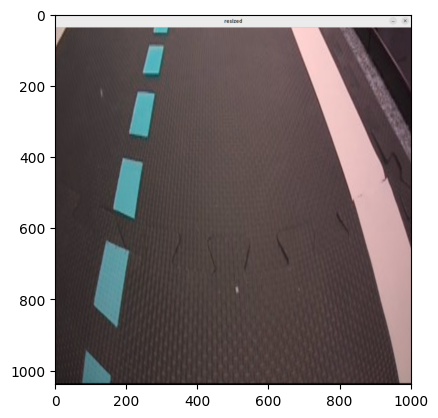

Exception in thread Thread-29 (show_img):
Traceback (most recent call last):
  File "/usr/lib/python3.10/threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "/home/duckie5/.local/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "/usr/lib/python3.10/threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "/tmp/ipykernel_58999/3636593514.py", line 4, in show_img
  File "/tmp/ipykernel_58999/277530386.py", line 34, in callback
  File "/tmp/ipykernel_58999/277530386.py", line 89, in update_conf
  File "/usr/lib/python3.10/tkinter/__init__.py", line 544, in get
    value = self._tk.globalgetvar(self._name)
RuntimeError: main thread is not in main loop


In [ ]:
import matplotlib.pyplot as plt
plt.imshow(img)

Thread(target=show_img,args=(node,)).start()
node.run()